In [4]:
#climate_change_impact_on_agriculture_2024_classification.csv
#global_data_on_sustainable_energy_regression.csv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder

from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score , accuracy_score


In [6]:
df_reg = pd.read_csv("global-data-on-sustainable-energy-regression.csv")
df_cls = pd.read_csv("climate_change_impact_on_agriculture_2024_classification.csv")

In [7]:
print("--- Regression Dataset Overview ---")
df_reg.info()
display(df_reg.head())

--- Regression Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   str    
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electric

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [8]:
print("--- Classification Dataset Overview ---")
df_cls.info()
display(df_cls.head())

--- Classification Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  str    
 2   Region                       10000 non-null  str    
 3   Crop_Type                    10000 non-null  str    
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  f

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [9]:
# Check for Missing Value in dataset
print("\nMissing Value in Regression Dataset\n", df_reg.isnull().sum())
print("\nMissing Value in Classfication Dataset\n", df_cls.isnull().sum())



Missing Value in Regression Dataset
 Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emi

# Dataset Understanding

## Regression Dataset
- This dataset contains sustainability and renewable energy indicators collected from different countries.
- Features include energy production, electricity access, GDP, CO₂ emissions, and renewable energy statistics.
- The objective is to predict a continuous target using Linear Regression.

## Classification Dataset
- This dataset contains climate change impacts on agriculture.
- The original target (Economic_Impact_Million_USD) was continuous.
- Therefore, feature engineering was performed to create three categories (Low, Medium, High) for Logistic Regression.

In [10]:
# --- STEP 3: Robust Data Cleaning ---

def robust_clean(df):
    # 1. Jo columns 100% khali hain, unhe pehle hi hata do (drop)
    df = df.dropna(axis=1, how='all')
    
    # 2. Bachi hui missing values ko fill karo
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            # Naya aur zyada safe tareeqa check karne ka ki column me numbers hain ya nahi
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
    return df

# Naye function se datasets ko clean karte hain
df_reg = robust_clean(df_reg)
df_cls = robust_clean(df_cls)

print("\n--- Missing Values Handled ---")
print("Remaining Nulls in Regression dataset:", df_reg.isnull().sum().sum())
print("Remaining Nulls in Classification dataset:", df_cls.isnull().sum().sum())


--- Missing Values Handled ---
Remaining Nulls in Regression dataset: 0
Remaining Nulls in Classification dataset: 0


In [13]:
print(df_reg.shape)

(3649, 21)


In [14]:
print("df_reg exists:", "df_reg" in globals())
print("df_cls exists:", "df_cls" in globals())

df_reg exists: True
df_cls exists: True


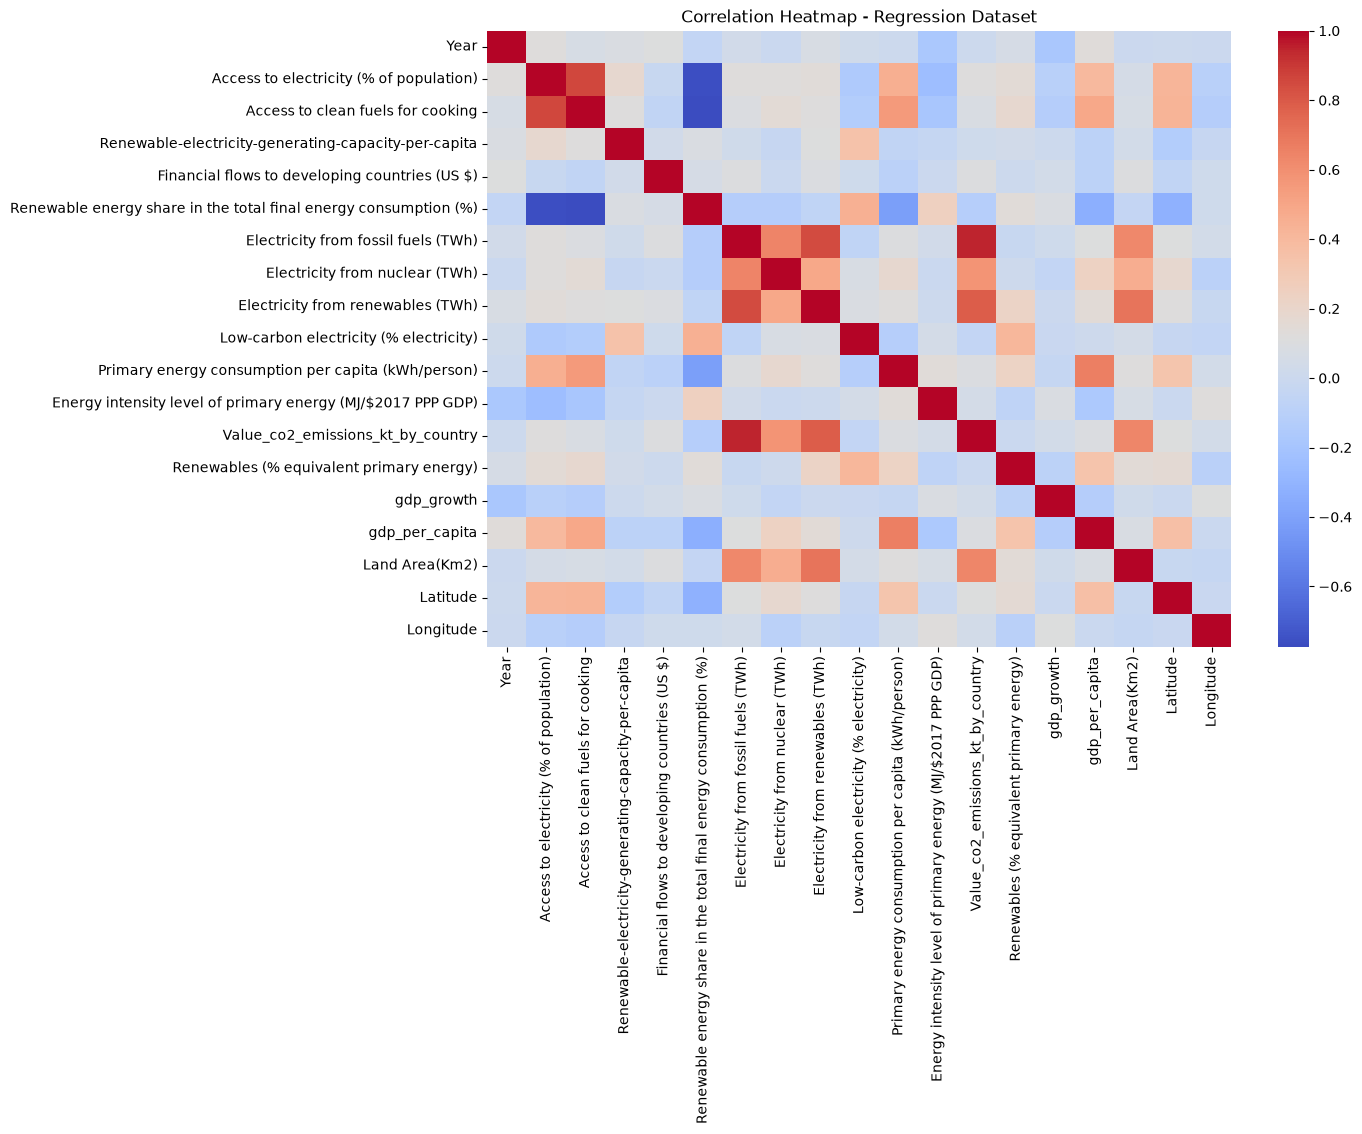

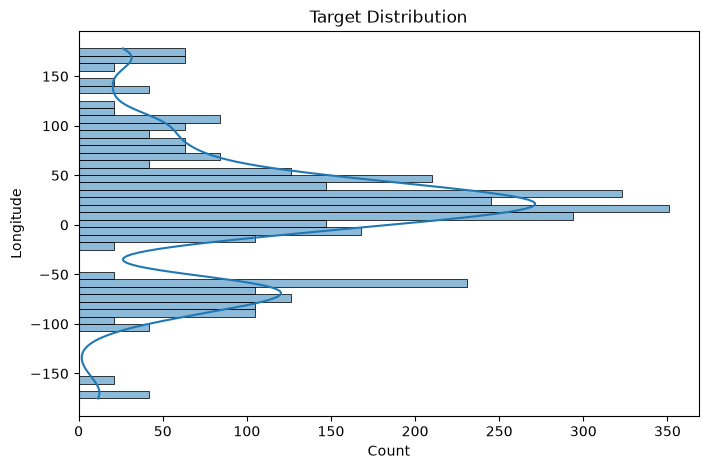

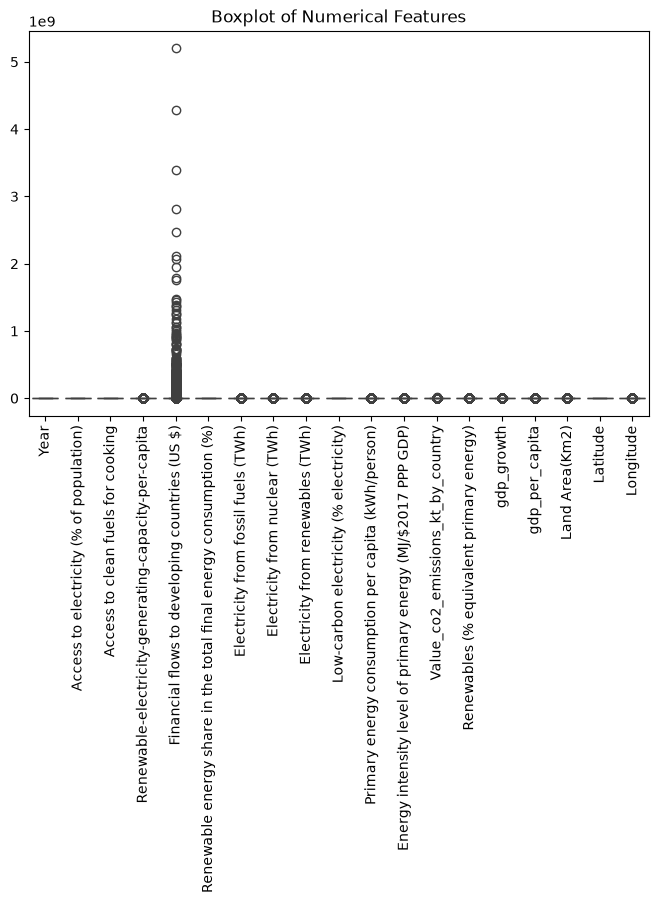

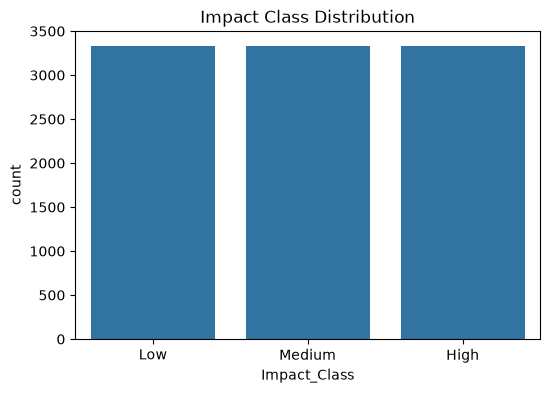

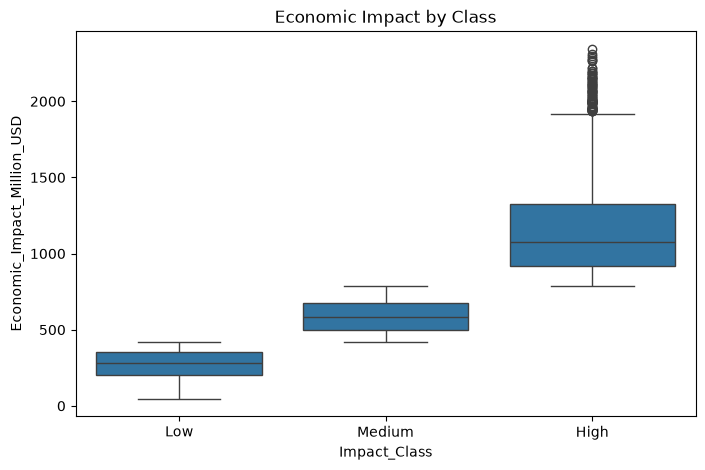

In [32]:
# ==========================
# Exploratory Data Analysis
# ==========================

plt.figure(figsize=(12,8))
sns.heatmap(df_reg.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap - Regression Dataset")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(y=df_reg.iloc[:,-1], data=df_reg, kde=True)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_reg.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Impact_Class", data=df_cls)
plt.title("Impact Class Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Impact_Class",
    y="Economic_Impact_Million_USD",
    data=df_cls
)
plt.title("Economic Impact by Class")
plt.show()

# Feature Relationships and Analysis

- Correlation heatmaps were used to identify relationships among numerical variables.
- Scatter plots helped visualize relationships between selected numerical features.
- Box plots were used to detect outliers.
- Count plots showed the distribution of classification categories.
- Histograms displayed the distribution of the target variable.

### Observations
- Some variables showed strong positive and negative correlations.
- Renewable energy indicators were related to environmental variables.
- Economic impact varied across the created impact classes.


In [ ]:
target_reg = df_reg.columns[-1]
target_cls = df_cls.columns[-1]

# Separate Features and Target
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

X_cls = df_cls.drop(columns=[target_cls])
y_cls = df_cls[target_cls]

# Convert categorical feature columns to numeric
X_reg = pd.get_dummies(X_reg, drop_first=True)
X_cls = pd.get_dummies(X_cls, drop_first=True)

# Encode classification target if it is text
if y_cls.dtype == 'object':
    le = LabelEncoder()
    y_cls = le.fit_transform(y_cls)

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Scale numerical features
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

scaler_cls = StandardScaler()
X_train_cls = scaler_cls.fit_transform(X_train_cls)
X_test_cls = scaler_cls.transform(X_test_cls)

In [19]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_reg = lr_model.predict(X_test_reg)

# Evaluation
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 3.177988515867246e-26
Root Mean Squared Error: 1.7826913686522538e-13
R2 Score: 1.0


In [24]:
# Create Low, Medium, High classes
df_cls['Impact_Class'] = pd.qcut(
    df_cls['Economic_Impact_Million_USD'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [27]:
X_cls = pd.get_dummies(X_cls, drop_first=True)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls)

# Prediction
y_pred_cls = log_model.predict(X_test_cls)

# Evaluation
acc = accuracy_score(y_test_cls, y_pred_cls)

print("Accuracy:", acc)
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_cls, y_pred_cls))

print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred_cls))

Accuracy: 0.986

Confusion Matrix:

[[669   0   8]
 [  0 639   6]
 [  5   9 664]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       677
           1       0.99      0.99      0.99       645
           2       0.98      0.98      0.98       678

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



# Model Insights

## Data Preprocessing
- Missing values were handled using median and mode.
- Categorical variables were converted into numerical values using pd.get_dummies().
- LabelEncoder was used to encode the target classes.
- StandardScaler standardized numerical features.
- The dataset was split into training (80%) and testing (20%).

## Model Performance
- Linear Regression predicted continuous values.
- Logistic Regression classified the data into Low, Medium and High impact classes.
- Performance was evaluated using MSE, RMSE, R² Score and Accuracy.

In [33]:
import joblib

joblib.dump(lr_model,"2026-07-15_LinearRegression.pkl")
joblib.dump(log_model,"2026-07-15_LogisticRegression.pkl")

print("Both models saved successfully.")

Both models saved successfully.


# Conclusion

This project analyzed two sustainability-related datasets using machine learning techniques.

The datasets were preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and performing feature engineering where required.

Linear Regression was used to predict a continuous target variable, while Logistic Regression classified the economic impact into Low, Medium, and High categories.

The models were evaluated using MSE, RMSE, R² Score, Accuracy, Confusion Matrix, and Classification Report. The results demonstrate how machine learning can support sustainability and green-skilling applications by enabling data-driven predictions and classification.
